In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("LoanApprovalPrediction.csv")

In [34]:
obj = (data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 7


In [35]:
# Dropping Loan_ID column
data.drop(['Loan_ID'],axis=1,inplace=True)

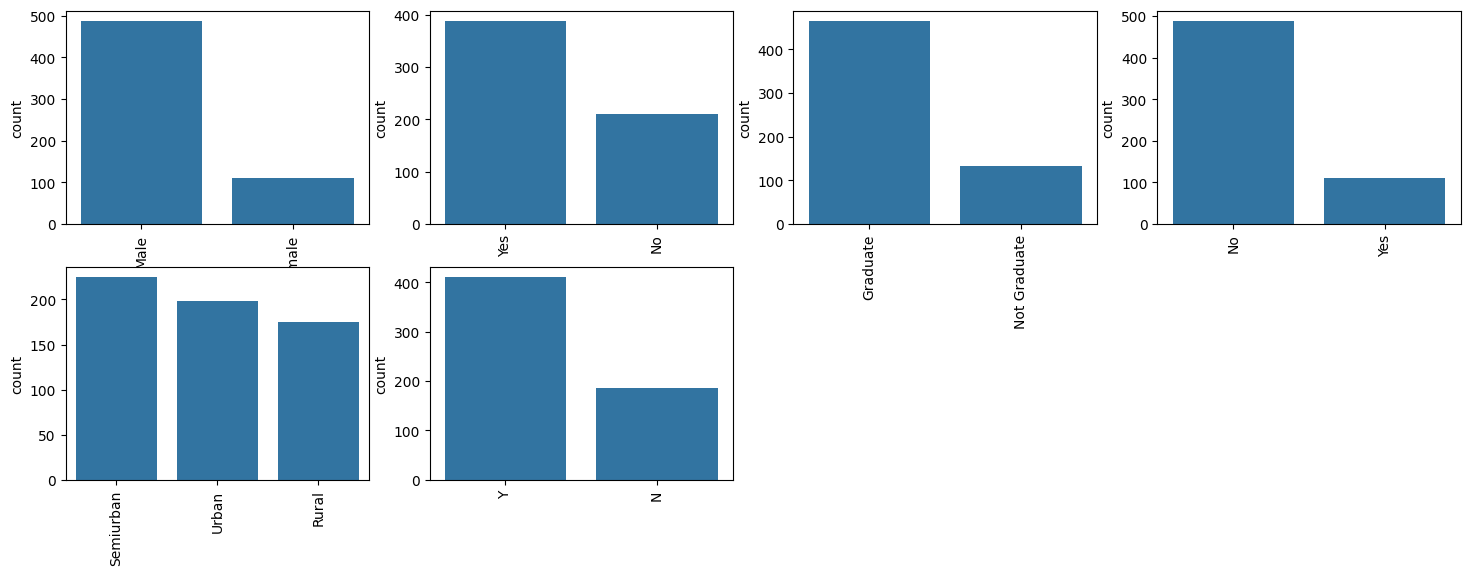

In [36]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.figure(figsize=(18,36))
index = 1

for col in object_cols:
  y = data[col].value_counts()
  plt.subplot(11,4,index)
  plt.xticks(rotation=90)
  sns.barplot(x=list(y.index), y=y)
  index +=1

In [37]:
data.isnull()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
593,False,False,False,False,False,False,False,False,False,False,False,False
594,False,False,False,False,False,False,False,False,False,False,False,False
595,False,False,False,False,False,False,False,False,False,False,False,False
596,False,False,False,False,False,False,False,False,False,False,False,False


In [38]:
data[data.isnull().any(axis=1)]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
16,Male,No,1.0,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,Male,Yes,0.0,Graduate,Yes,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,Male,Yes,1.0,Graduate,Yes,3717,2925.0,151.0,360.0,NaN,Semiurban,N
29,Male,Yes,1.0,Graduate,Yes,4166,3369.0,201.0,360.0,NaN,Urban,N
...,...,...,...,...,...,...,...,...,...,...,...,...
558,Male,Yes,NaN,Graduate,No,5116,1451.0,165.0,360.0,0.0,Urban,N
569,Male,Yes,1.0,Graduate,No,1880,0.0,61.0,360.0,NaN,Rural,N
581,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
584,Female,No,3.0,Graduate,Yes,416,41667.0,350.0,180.0,NaN,Urban,N


In [39]:
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [40]:
# Convert target if it is Y/N
y = y.map({"Y": 1, "N": 0})

In [41]:
# 3. Train-test split FIRST
# --------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
# 4. Identify numerical and categorical columns
# --------------------------------------------------

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
#. Numerical preprocessing

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [44]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [45]:
from sklearn.compose import ColumnTransformer
#  Combine preprocessing
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])


In [50]:
# Create complete ML pipeline
# --------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [51]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Credit_History',
                                                   'Property_Area'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [52]:
y_pred = model.predict(X_test)


In [53]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8166666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.47      0.62        38
           1       0.80      0.98      0.88        82

    accuracy                           0.82       120
   macro avg       0.85      0.72      0.75       120
weighted avg       0.83      0.82      0.80       120



In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    params,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)

ValueError: 
All the 150 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py", line 360, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        ensure_all_finite=False,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/loca

In [56]:
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------------
# 1. Separate X and y
# --------------------------------------------------



# Remove Loan_ID because it is just an identifier
if "Loan_ID" in X.columns:
    X = X.drop("Loan_ID", axis=1)


# --------------------------------------------------
# 2. Train-test split FIRST
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 3. Automatically identify column types
# --------------------------------------------------

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns


# --------------------------------------------------
# 4. Numerical preprocessing
# --------------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# --------------------------------------------------
# 5. Categorical preprocessing
# --------------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# --------------------------------------------------
# 6. Combine preprocessing
# --------------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


# --------------------------------------------------
# 7. Complete Random Forest pipeline
# --------------------------------------------------

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])


# --------------------------------------------------
# 8. Hyperparameter grid
# --------------------------------------------------

param_grid = {
    "classifier__n_estimators": [100, 200, 400, 600],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"]
}


# --------------------------------------------------
# 9. Randomized Search
# --------------------------------------------------

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)


# --------------------------------------------------
# 10. Train
# --------------------------------------------------

search.fit(X_train, y_train)


# --------------------------------------------------
# 11. Best parameters
# --------------------------------------------------

print("Best Parameters:")
print(search.best_params_)


# --------------------------------------------------
# 12. Prediction
# --------------------------------------------------

y_pred = search.predict(X_test)


# --------------------------------------------------
# 13. Evaluation
# --------------------------------------------------

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__class_weight': None}

Test Accuracy:
0.8041666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.44      0.58        75
           1       0.79      0.97      0.87       165

    accuracy                           0.80       240
   macro avg       0.83      0.70      0.73       240
weighted avg       0.82      0.80      0.78       240

